<a href="https://colab.research.google.com/github/AmandaHeape/ISYS2001/blob/main/Assessment_2/Finance_Project_Amanda_Heape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Defining the Finance Problem

A Spending Pattern Analyser that helps a user understand where their money goes.

A Savings Goal Planner that calculates how long it will take to reach a target.

The assistant 'Alfie' helps a user understand their spending behaviour by analysing their transaction CSV and providing personalised insights


# Inputs and Outputs

Inputs

1. user‑uploaded CSV of transactions
2. user‑entered numbers (budget, savings goal, categories)

Outputs
1. Summaries based on their data
2. Custom tool result (category breakdown, savings projection)
3. Conversational responses from Alfie that reference the analysis

*Sample data*

In [5]:
csv_text = """
date,merchant,category,amount
2024-01-03,Woolworths,Groceries,54.20
2024-01-05,Spotify,Entertainment,12.99
2024-01-07,Coles,Groceries,33.10
2024-01-10,Uber,Transport,18.50
2024-01-12,Kmart,Shopping,45.00
2024-01-15,7-Eleven,Snacks,8.90
2024-01-18,Officeworks,Shopping,29.95
2024-01-22,Dominos,Food,21.50
2024-02-02,Woolworths,Groceries,62.40
2024-02-04,Netflix,Entertainment,16.99
2024-02-06,Shell,Transport,52.00
2024-02-09,Myer,Shopping,120.00
2024-02-12,JB Hi-Fi,Electronics,89.00
2024-02-15,McDonalds,Food,14.75
2024-02-18,Amazon,Online Shopping,37.99
"""

with open("sample_transactions.csv", "w") as f:
    f.write(csv_text)

print("CSV file created")


CSV file created


In [ ]:
import pandas as pd

df = pd.read_csv("sample_transactions.csv")
df


,date,merchant,category,amount
0,2024-01-03,Woolworths,Groceries,54.20
1,2024-01-05,Spotify,Entertainment,12.99
2,2024-01-07,Coles,Groceries,33.10
3,2024-01-10,Uber,Transport,18.50
4,2024-01-12,Kmart,Shopping,45.00
5,2024-01-15,7-Eleven,Snacks,8.90
6,2024-01-18,Officeworks,Shopping,29.95
7,2024-01-22,Dominos,Food,21.50
8,2024-02-02,Woolworths,Groceries,62.40
9,2024-02-04,Netflix,Entertainment,16.99


Total spending across all transactions: $617.17

Spending by category:
* Groceries: $149.70

* Entertainment: $29.98

* Transport: $70.50

* Shopping: $194.95

* Snacks: $8.90  

* Food: $36.25  

* Electronics: $89.00  

* Online Shopping: $37.99

Largest merchant by total spend = Myer ($120.00)

Monthly totals:
* January: $224.14

* February: $393.03

With a savings goal of $300/month, January met the goal, while February overspent.

# Pseudocode
Alfie helps a user understand their spending behaviour by analysing their transaction CSV and providing personalised insights.

Alfie also supports savings planning by estimating how long it will take to reach a financial target.

# 1. Input & Validation

START

Prompt user to upload a CSV file of transactions.

TRY:
    Load the CSV into a table-like structure.
EXCEPT:
    Display: "I couldn't read your file. Please upload a valid CSV."
    STOP.

Check that the CSV contains the required columns:
    - date
    - merchant
    - category
    - amount

IF any required column is missing:
    Display: "Your CSV is missing required columns."
    STOP.


In [25]:
from google.colab import userdata
from google import genai

# The client reads your key from Secrets, so the key itself never appears here.
client = genai.Client(api_key=userdata.get("GOOGLE_API_KEY"))

# The flash model is fast and free-tier friendly. The exact name changes every
# few months, so check AI Studio for the current one and edit this single line.
MODEL = "gemini-3.5-flash"

print("Connected to the Gemini API.")

Connected to the Gemini API.


In [27]:
import os
import io
import pandas as pd
from google.colab import files

# Try importing the official Google GenAI SDK and Pydantic
try:
    from google import genai
    from google.genai import types
    from pydantic import BaseModel
except ImportError:
    # Automatically install if not present in the environment
    !pip install -q google-genai pydantic
    from google import genai
    from google.genai import types
    from pydantic import BaseModel

def get_and_validate_user_file():
    """
    Prompts the user to upload a CSV or PDF file.
    If it's a PDF, uses Gemini to parse transactions into the standard CSV format.
    Otherwise, reads and validates it as a CSV.
    """
    print("Hello! I'm Alfie, your friendly finance assistant. Let's get your transactions loaded! \n")
    print("Please upload your transaction file below (either a clean CSV or a PDF Bank Statement).")

    try:
        uploaded = files.upload()
        if not uploaded:
            print("\n[Alfie Info] No file was uploaded. Let's fall back to our 'sample_transactions.csv' for testing!")
            file_path = "sample_transactions.csv"
        else:
            file_path = list(uploaded.keys())[0]
            print(f"\n[Success] Uploaded file '{file_path}' successfully!")
    except Exception as upload_error:
        print(f"\n[Alfie Info] Upload prompt skipped or unavailable. Falling back to 'sample_transactions.csv' for testing!")
        file_path = "sample_transactions.csv"

    df = None

    # Check if the file is a PDF
    if file_path.lower().endswith('.pdf'):
        print("\n[Alfie Processing] Ooh, a PDF bank statement! Let's get Gemini to extract the transactions for us...")

        # Retrieve the API key from Colab User Secrets
        from google.colab import userdata
        try:
            # Check for either GEMINI_API_KEY or GOOGLE_API_KEY
            api_key = None
            for key_name in ['GEMINI_API_KEY', 'GOOGLE_API_KEY']:
                try:
                    api_key = userdata.get(key_name)
                    if api_key:
                        break
                except Exception:
                    continue

            if not api_key:
                raise ValueError("Neither GEMINI_API_KEY nor GOOGLE_API_KEY was found in your Colab Secrets.")

            client = genai.Client(api_key=api_key)

            # Read PDF raw bytes to pass to the API
            with open(file_path, "rb") as f:
                pdf_bytes = f.read()

            # Correctly define schemas using Pydantic's BaseModel
            class TransactionSchema(BaseModel):
                date: str
                merchant: str
                category: str
                amount: float

            class StatementSchema(BaseModel):
                transactions: list[TransactionSchema]

            # Retrieve model dynamically from global workspace, default to gemini-2.5-flash if missing
            chosen_model = globals().get('MODEL', 'gemini-2.5-flash')

            # Request extraction from Gemini using the configured model
            response = client.models.generate_content(
                model=chosen_model,
                contents=[
                    types.Part.from_bytes(data=pdf_bytes, mime_type='application/pdf'),
                    "Extract all bank transactions from this statement. Convert all dates to standard 'YYYY-MM-DD' format and map transactions into the requested structure. Use common categories like Groceries, Entertainment, Transport, Shopping, Snacks, Food, and Electronics."
                ],
                config=types.GenerateContentConfig(
                    response_mime_type="application/json",
                    response_schema=StatementSchema
                )
            )

            # Parse structured JSON directly into a pandas DataFrame
            import json
            raw_data = json.loads(response.text)
            df = pd.DataFrame(raw_data['transactions'])
            print(f"[Success] Gemini ({chosen_model}) successfully extracted and structured your transactions!")

        except Exception as err:
            print(f"\n[Error] Could not process PDF with Gemini. Details: {err}")
            print("Please ensure you've added your 'GOOGLE_API_KEY' or 'GEMINI_API_KEY' to your Colab secrets (the key icon on the left panel)!")
            print("Falling back to 'sample_transactions.csv' instead.")
            df = pd.read_csv("sample_transactions.csv")
    else:
        # Fallback/Default path: Handle standard CSV files
        try:
            df = pd.read_csv(file_path)
            df.columns = df.columns.str.strip()
            print("[Success] I was able to read the CSV file perfectly!")
        except Exception as e:
            print(f"[Error] I couldn't read your file. Please make sure it is a valid CSV format. Details: {e}")
            return None

    # Final Validation of the DataFrame Columns
    if df is None:
        print("[Error] No transaction data was loaded.")
        return None

    required_columns = ['date', 'merchant', 'category', 'amount']
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        print(f"[Error] This table is missing required columns: {missing_columns}")
        return None
    else:
        print("[Success] All required columns ('date', 'merchant', 'category', 'amount') are present!")
        print("\nYour transaction data is ready for analysis! You're doing great!")
        print("\nHere is a preview of your data:")
        display(df.head())
        return df

# Let's run our updated file validator!
validated_df = get_and_validate_user_file()

Hello! I'm Alfie, your friendly finance assistant. Let's get your transactions loaded! 

Please upload your transaction file below (either a clean CSV or a PDF Bank Statement).


Saving PDF document-8DEF8804EE83-1.pdf to PDF document-8DEF8804EE83-1 (5).pdf

[Success] Uploaded file 'PDF document-8DEF8804EE83-1 (5).pdf' successfully!

[Alfie Processing] Ooh, a PDF bank statement! Let's get Gemini to extract the transactions for us...
[Success] Gemini (gemini-3.5-flash) successfully extracted and structured your transactions!
[Success] All required columns ('date', 'merchant', 'category', 'amount') are present!

Your transaction data is ready for analysis! You're doing great!

Here is a preview of your data:


,date,merchant,category,amount
0,2026-07-06,DD *DOORDASH NANDO MELBOURNE AUS,Food,30.47
1,2026-07-06,HJs Cockburn Cockburn AUS,Food,4.05
2,2026-07-06,AMPOL COCKBURN 510 JANDAKOT AUS,Transport,63.82
3,2026-07-06,COLES 0380 SCARBOROUGH AUS,Groceries,38.25
4,2026-07-06,WOOLWORTHS 43 PERTH AUS,Groceries,11.90


# 2. Cleaning Data

Convert date column into actual date objects

Remove rows where amount is missing or not a number

Sort transactions by date (oldest to newest)


In [29]:
import pandas as pd

def clean_transaction_data(df):
    """
    Cleans and prepares the transaction DataFrame:
    - Converts date to datetime format (coercing errors)
    - Converts amount to numeric format
    - Drops rows with missing dates or amounts
    - Cleans and standardises category and merchant columns
    - Sorts the transactions chronologically
    """
    if df is None or df.empty:
        print("[Alfie Error] No data available to clean!")
        return None

    # Create a copy to avoid SettingWithCopyWarnings
    cleaned_df = df.copy()

    # 1. Convert 'date' column to datetime. Invalid dates become NaT (Not a Time)
    cleaned_df['date'] = pd.to_datetime(cleaned_df['date'], errors='coerce')

    # 2. Convert 'amount' column to numeric. Invalid entries become NaN
    cleaned_df['amount'] = pd.to_numeric(cleaned_df['amount'], errors='coerce')

    # 3. Drop rows where critical fields ('date' or 'amount') are missing
    initial_rows = len(cleaned_df)
    cleaned_df = cleaned_df.dropna(subset=['date', 'amount'])

    # 4. Standardise textual columns (strip whitespace, convert to Title Case)
    for col in ['merchant', 'category']:
        if col in cleaned_df.columns:
            cleaned_df[col] = cleaned_df[col].astype(str).str.strip().str.title()
            # Replace empty strings or string-based 'Nan' values with 'Unknown'
            cleaned_df[col] = cleaned_df[col].replace({'': 'Unknown', 'Nan': 'Unknown'})

    # 5. Sort transactions chronologically (oldest to newest)
    cleaned_df = cleaned_df.sort_values(by='date').reset_index(drop=True)

    dropped_rows = initial_rows - len(cleaned_df)
    print("[Alfie Status] Data cleaning complete!")
    if dropped_rows > 0:
        print(f" - Removed {dropped_rows} row(s) with invalid dates or amounts.")
    else:
        print(" - All rows had valid dates and amounts!")
    print(f" - Sorted {len(cleaned_df)} transactions chronologically.")

    return cleaned_df

# Clean our validated DataFrame and preview it!
cleaned_df = clean_transaction_data(validated_df)
display(cleaned_df.head())

[Alfie Status] Data cleaning complete!
 - All rows had valid dates and amounts!
 - Sorted 79 transactions chronologically.


,date,merchant,category,amount
0,2026-07-06,Dd *Doordash Nando Melbourne Aus,Food,30.47
1,2026-07-06,Hjs Cockburn Cockburn Aus,Food,4.05
2,2026-07-06,Ampol Cockburn 510 Jandakot Aus,Transport,63.82
3,2026-07-06,Coles 0380 Scarborough Aus,Groceries,38.25
4,2026-07-06,Woolworths 43 Perth Aus,Groceries,11.90


# 3. Calculate Spending Summaries

*Total Spending*

Set total_spending = 0

FOR each transaction:
    total_spending = total_spending + amount

*Spending by Category*

Create empty dictionary category_totals

FOR each transaction:
    category = transaction.category
    amount = transaction.amount

    IF category not in category_totals:
        category_totals[category] = amount
    ELSE:
        category_totals[category] = category_totals[category] + amount

*Largest Merchant*

Create empty dictionary merchant_totals

FOR each transaction:
    merchant = transaction.merchant
    amount = transaction.amount

    IF merchant not in merchant_totals:
        merchant_totals[merchant] = amount
    ELSE:
        merchant_totals[merchant] = merchant_totals[merchant] + amount

Identify merchant with highest total_spend in merchant_totals.

*Monthly Spending Totals*

Create empty dictionary monthly_totals

FOR each transaction:
    month_key = extract YYYY-MM from transaction.date
    amount = transaction.amount

    IF month_key not in monthly_totals:
        monthly_totals[month_key] = amount
    ELSE:
        monthly_totals[month_key] = monthly_totals[month_key] + amount


In [30]:
def calculate_spending_summaries(df):
    """
    Calculates spending summaries using core Python loops and dictionaries.
    """
    if df is None or df.empty:
        print("[Alfie Error] No clean data available to calculate summaries!")
        return None

    # 1. Total Spending
    total_spending = 0.0
    for amount in df['amount']:
        total_spending += amount

    # 2. Spending by Category
    category_totals = {}
    for index, row in df.iterrows():
        cat = row['category']
        amt = row['amount']
        if cat not in category_totals:
            category_totals[cat] = amt
        else:
            category_totals[cat] += amt

    # 3. Largest Merchant
    merchant_totals = {}
    for index, row in df.iterrows():
        merch = row['merchant']
        amt = row['amount']
        if merch not in merchant_totals:
            merchant_totals[merch] = amt
        else:
            merchant_totals[merch] += amt

    # Identify the merchant with the highest total spend
    largest_merchant = None
    max_merchant_spend = 0.0
    for merchant, total in merchant_totals.items():
        if total > max_merchant_spend:
            max_merchant_spend = total
            largest_merchant = merchant

    # 4. Monthly Spending Totals
    monthly_totals = {}
    for index, row in df.iterrows():
        # Extract YYYY-MM from the datetime object
        month_key = row['date'].strftime('%Y-%m')
        amt = row['amount']
        if month_key not in monthly_totals:
            monthly_totals[month_key] = amt
        else:
            monthly_totals[month_key] += amt

    # Display the results nicely!
    print("[Alfie Status] Calculations are complete! Here's a quick summary:")
    print(f" - Total Spending: ${total_spending:,.2f}")
    print(f" - Largest Merchant: {largest_merchant} (${max_merchant_spend:,.2f})")

    print("\nSpending by Category:")
    for cat, total in category_totals.items():
        print(f" * {cat}: ${total:,.2f}")

    print("\nMonthly Spending Totals:")
    for month, total in monthly_totals.items():
        print(f" * {month}: ${total:,.2f}")

    return {
        'total_spending': total_spending,
        'category_totals': category_totals,
        'merchant_totals': merchant_totals,
        'largest_merchant': largest_merchant,
        'max_merchant_spend': max_merchant_spend,
        'monthly_totals': monthly_totals
    }

# Run the summary calculations on our cleaned data!
summaries = calculate_spending_summaries(cleaned_df)

[Alfie Status] Calculations are complete! Here's a quick summary:
 - Total Spending: $4,790.86
 - Largest Merchant: Bunnings Jandakot 2160Jandakot Wa Au ($649.82)

Spending by Category:
 * Food: $421.16
 * Transport: $595.41
 * Groceries: $86.85
 * Shopping: $2,591.29
 * Entertainment: $253.66
 * Other: $818.49
 * Snacks: $24.00

Monthly Spending Totals:
 * 2026-07: $1,994.63
 * 2026-08: $1,560.45
 * 2026-09: $883.71
 * 2026-10: $352.07


# 4. Savings Goal Planner

Prompt user for monthly_savings_goal (e.g., $300)

FOR each month in monthly_totals:
    spending = monthly_totals[month]
    savings = monthly_savings_goal - spending
    Store savings result for that month

Calculate average_monthly_savings across all months

IF average_monthly_savings <= 0:
    User cannot reach savings goal with current spending
ELSE:
    Prompt user for target_amount (e.g., $2000)
    months_needed = target_amount / average_monthly_savings


In [31]:
def plan_savings_goals(monthly_totals):
    """
    Interactively guides the user to set a monthly budget/savings goal
    and calculates how long it will take to reach a financial target.
    """
    if not monthly_totals:
        print("[Alfie Error] No monthly spending records found. Please calculate summaries first!")
        return None

    print("Hello! Let's work out your savings goal projection together!\n")

    # 1. Ask user for their target monthly budget/income to save from
    try:
        monthly_income_input = input("Enter your monthly income or the budget limit you want to save from (e.g., 600): ")
        monthly_budget = float(monthly_income_input)
    except ValueError:
        print("[Alfie Info] Invalid input. Defaulting to a budget limit of $600.00 for testing.")
        monthly_budget = 600.0

    # 2. Calculate savings for each month (Budget - Actual Spending)
    savings_by_month = {}
    total_savings = 0.0

    print("\nCalculating your savings month-by-month:")
    for month, spending in monthly_totals.items():
        monthly_savings = monthly_budget - spending
        savings_by_month[month] = monthly_savings
        total_savings += monthly_savings
        print(f" * {month}: Budget ${monthly_budget:,.2f} - Spent ${spending:,.2f} = Saved ${monthly_savings:,.2f}")

    # 3. Calculate average monthly savings
    num_months = len(monthly_totals)
    average_monthly_savings = total_savings / num_months
    print(f"\n[Alfie Status] Your average monthly savings: ${average_monthly_savings:,.2f}")

    # 4. Check if they are saving anything on average
    if average_monthly_savings <= 0:
        print("\n[Alfie Insight] It looks like your average spending exceeds your monthly budget limit!")
        print("To reach your savings goals, we might need to look at cutting back some category costs.")
        return {
            'savings_by_month': savings_by_month,
            'average_monthly_savings': average_monthly_savings,
            'months_needed': None
        }

    # 5. Prompt for total target savings amount
    try:
        target_amount_input = input("\nEnter the financial target amount you want to save up for (e.g., 2000): ")
        target_amount = float(target_amount_input)
    except ValueError:
        print("[Alfie Info] Invalid input. Defaulting to a target amount of $2000.00 for testing.")
        target_amount = 2000.0

    # 6. Calculate months needed to reach target
    months_needed = target_amount / average_monthly_savings

    print(f"\n[Alfie Success] To reach your target of ${target_amount:,.2f}:")
    print(f" - It will take approximately {months_needed:.1f} months of saving at your current pace!")
    print("You've got this! Small adjustments add up to big milestones.")

    return {
        'savings_by_month': savings_by_month,
        'average_monthly_savings': average_monthly_savings,
        'target_amount': target_amount,
        'months_needed': months_needed
    }

# Run the planner using our calculated monthly totals!
savings_results = plan_savings_goals(summaries['monthly_totals'])

Hello! Let's work out your savings goal projection together!

Enter your monthly income or the budget limit you want to save from (e.g., 600): 2400

Calculating your savings month-by-month:
 * 2026-07: Budget $2,400.00 - Spent $1,994.63 = Saved $405.37
 * 2026-08: Budget $2,400.00 - Spent $1,560.45 = Saved $839.55
 * 2026-09: Budget $2,400.00 - Spent $883.71 = Saved $1,516.29
 * 2026-10: Budget $2,400.00 - Spent $352.07 = Saved $2,047.93

[Alfie Status] Your average monthly savings: $1,202.29

Enter the financial target amount you want to save up for (e.g., 2000): 1000

[Alfie Success] To reach your target of $1,000.00:
 - It will take approximately 0.8 months of saving at your current pace!
You've got this! Small adjustments add up to big milestones.


# 5. Visuals

Pie Chart - Spending by Category
    Use category_totals to create a pie chart.
    Title: "Spending by Category".

Bar Chart - Monthly Spending Totals
    Use monthly_totals to create a bar chart.
    Title: "Monthly Spending Totals".

Line Graph - Spending Over Time
    Use date and amount columns to create a line graph.
    Title: "Spending Over Time".

Horizontal Bar Chart - Top Merchants
    Use merchant_totals to create a horizontal bar chart.
    Title: "Top Merchants by Total Spend".

Store all figures for display in interface.

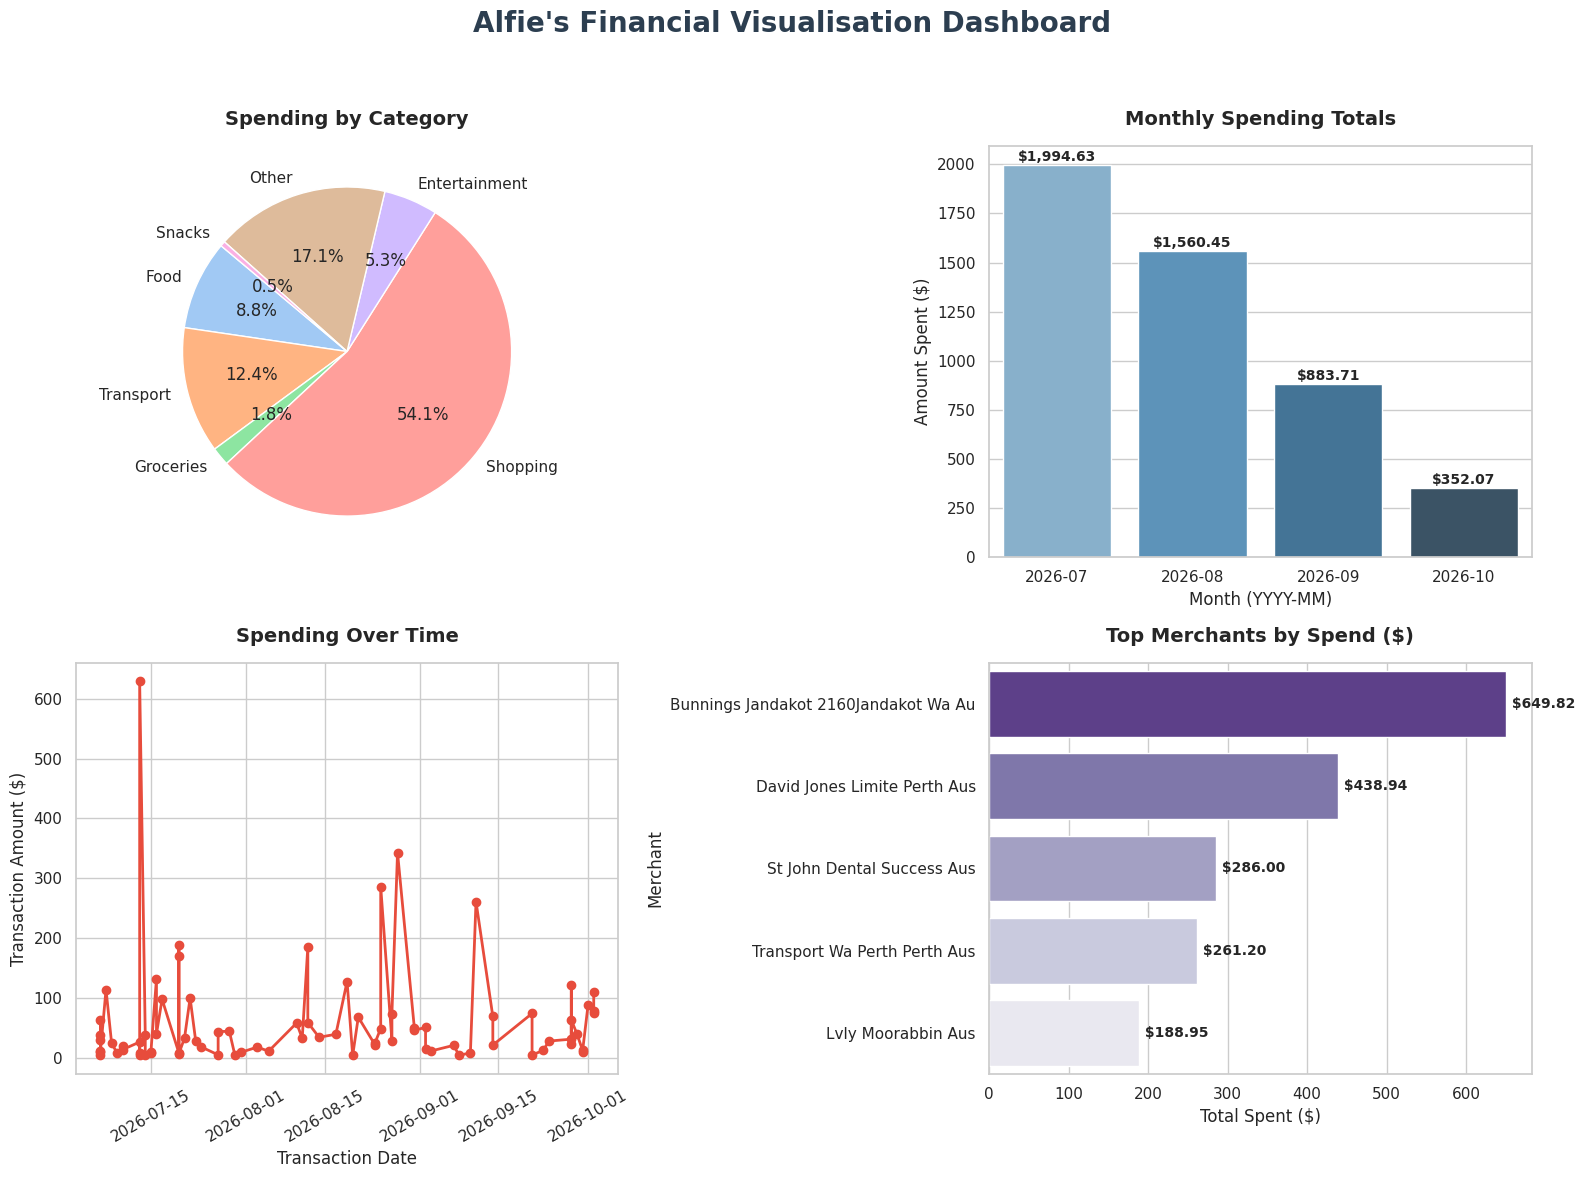

[Alfie Status] Beautiful dashboards are ready for your review!


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def generate_spending_visuals(df, summaries):
    """
    Generates 4 key financial charts to help the user visualize their spending:
    - Pie Chart (Spending by Category)
    - Bar Chart (Monthly Spending Totals)
    - Line Graph (Spending Over Time)
    - Horizontal Bar Chart (Top Merchants by Spend)
    """
    if df is None or df.empty or not summaries:
        print("[Alfie Error] No data or summaries available to plot!")
        return

    # Use a clean style for visual appeal
    sns.set_theme(style="whitegrid")

    # Set up a 2x2 grid for our subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle("Alfie's Financial Visualisation Dashboard", fontsize=20, weight='bold', color='#2c3e50', y=0.98)

    # 1. Pie Chart: Spending by Category
    cat_totals = summaries['category_totals']
    categories = list(cat_totals.keys())
    cat_values = list(cat_totals.values())

    axes[0, 0].pie(cat_values, labels=categories, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    axes[0, 0].set_title("Spending by Category", fontsize=14, weight='bold', pad=15)

    # 2. Bar Chart: Monthly Spending Totals
    monthly_totals = summaries['monthly_totals']
    months = list(monthly_totals.keys())
    month_values = list(monthly_totals.values())

    # Correcting Seaborn FutureWarning by assigning hue and setting legend=False
    sns.barplot(x=months, y=month_values, ax=axes[0, 1], palette="Blues_d", hue=months, legend=False)
    axes[0, 1].set_title("Monthly Spending Totals", fontsize=14, weight='bold', pad=15)
    axes[0, 1].set_xlabel("Month (YYYY-MM)")
    axes[0, 1].set_ylabel("Amount Spent ($)")
    for idx, val in enumerate(month_values):
        axes[0, 1].text(idx, val + 5, f"${val:,.2f}", ha='center', va='bottom', fontsize=10, weight='bold')

    # 3. Line Graph: Spending Over Time (Chronological Order)
    axes[1, 0].plot(df['date'], df['amount'], marker='o', color='#e74c3c', linewidth=2, markersize=6)
    axes[1, 0].set_title("Spending Over Time", fontsize=14, weight='bold', pad=15)
    axes[1, 0].set_xlabel("Transaction Date")
    axes[1, 0].set_ylabel("Transaction Amount ($)")
    axes[1, 0].tick_params(axis='x', rotation=30)

    # 4. Horizontal Bar Chart: Top Merchants by Spend
    merch_totals = summaries['merchant_totals']
    # Sort merchants by highest spend
    sorted_merchants = sorted(merch_totals.items(), key=lambda x: x[1], reverse=True)[:5] # Top 5
    merchants = [item[0] for item in sorted_merchants]
    merch_values = [item[1] for item in sorted_merchants]

    # Correcting Seaborn FutureWarning by assigning hue and setting legend=False
    sns.barplot(x=merch_values, y=merchants, ax=axes[1, 1], palette="Purples_r", hue=merchants, legend=False)
    axes[1, 1].set_title("Top Merchants by Spend ($)", fontsize=14, weight='bold', pad=15)
    axes[1, 1].set_xlabel("Total Spent ($)")
    axes[1, 1].set_ylabel("Merchant")
    for idx, val in enumerate(merch_values):
        axes[1, 1].text(val + 1, idx, f" ${val:,.2f}", ha='left', va='center', fontsize=10, weight='bold')

    # Adjust spacing dynamically to avoid overlap
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    print("[Alfie Status] Beautiful dashboards are ready for your review!")

# Generate and show the plots!
generate_spending_visuals(cleaned_df, summaries)

# 6. Alfie’s Personalised Insights

Create summary_text containing:
    - total_spending
    - top categories
    - largest merchant
    - monthly_totals
    - savings results

Send summary_text to Gemini with Alfie's persona:
    "You are Alfie, a friendly finance assistant who explains spending patterns clearly."

    - Friendly, supportive finance assistant.
    - Speaks clearly and simply.
    - Helps users understand spending patterns.
    - Provides insights based ONLY on the user's data.
    - Reminds users that he is not a financial advisor.

Add financial disclaimer to Alfie's system instruction:
    "Always consider speaking with a qualified professional for financial decisions."

Receive Alfie's personalised response.

Display Alfie's message to the user.


In [34]:
from google.colab import userdata
try:
    from google import genai
    from google.genai import types
except ImportError:
    !pip install -q google-genai
    from google import genai
    from google.genai import types

def get_alfies_insights(summaries, savings_results):
    """
    Generates conversational financial insights from Alfie using the configured Gemini model.
    """
    # 1. Retrieve the Gemini API Key from Colab Secrets (supporting both names)
    try:
        api_key = None
        for key_name in ['GEMINI_API_KEY', 'GOOGLE_API_KEY']:
            try:
                api_key = userdata.get(key_name)
                if api_key:
                    break
            except Exception:
                continue

        if not api_key:
            raise ValueError("No API Key found.")

        client = genai.Client(api_key=api_key)
    except Exception as e:
        print("[Alfie Error] Unable to retrieve API Key from Secrets.")
        print("Please ensure you've added your 'GOOGLE_API_KEY' or 'GEMINI_API_KEY' secret to the panel on the left (key icon).")
        return "Hi there! I'm Alfie. I've prepared your data, but I need an API key to give you my personalised analysis! Please configure your secrets in Colab so we can chat."

    # 2. Build the context summary string from our computed values
    category_text = "\n".join([f" - {cat}: ${amt:,.2f}" for cat, amt in summaries['category_totals'].items()])
    monthly_text = "\n".join([f" - {mth}: ${amt:,.2f}" for mth, amt in summaries['monthly_totals'].items()])

    savings_text = ""
    if savings_results and savings_results.get('average_monthly_savings', 0) > 0:
        savings_text = (
            f"Their average monthly savings is ${savings_results['average_monthly_savings']:,.2f}. "
            f"To save up to their target of ${savings_results['target_amount']:,.2f}, "
            f"it will take them approximately {savings_results['months_needed']:.1f} months."
        )
    else:
        savings_text = "Currently, they are overspending on average relative to their target savings limits."

    prompt = f"""
    Here is the user's transaction summary data:
    - Total Spending: ${summaries['total_spending']:,.2f}
    - Largest Merchant: {summaries['largest_merchant']} (${summaries['max_merchant_spend']:,.2f})

    Spending by Category:
    {category_text}

    Monthly Totals:
    {monthly_text}

    Savings Outlook:
    {savings_text}
    """

    # 3. Request insights from Gemini with Alfie's Persona and instructions
    try:
        # Retrieve model dynamically from global workspace, default to gemini-2.5-flash if missing
        chosen_model = globals().get('MODEL', 'gemini-2.5-flash')
        print(f"[Alfie Processing] Generating insights with {chosen_model}... Please wait a moment!")

        response = client.models.generate_content(
            model=chosen_model,
            contents=prompt,
            config=types.GenerateContentConfig(
                system_instruction=(
                    "You are Alfie, a friendly, supportive personal finance assistant. "
                    "Explain the spending patterns clearly and encouragingly. "
                    "Keep your response conversational, clear, and easy to read. "
                    "Base your insights ONLY on the provided user transaction details. "
                    "Never assume or invent other facts. "
                    "You must conclude with a short, helpful financial disclaimer stating that you "
                    "are an AI assistant and always consider speaking with a qualified professional "
                    "for professional financial decisions."
                ),
                temperature=0.7
            )
        )
        return response.text
    except Exception as err:
        print(f"[Alfie Error] Couldn't connect to the AI model. Details: {err}")
        return "Oh dear, I had some trouble talking to my brain servers! Let's double check your internet connection or API Key."

# Let's run Alfie's insights generation!
alfies_response = get_alfies_insights(summaries, savings_results)
print("\n--- Alfie's Personalised Response ---")
print(alfies_response)

[Alfie Processing] Generating insights with gemini-3.5-flash... Please wait a moment!

--- Alfie's Personalised Response ---
Hi there! I'm Alfie, your personal finance assistant, and I've been looking over your transaction summary. You have some really great momentum building here, and I'm excited to walk you through your progress!

### The Big Picture & Your Amazing Progress
Your total spending for this period was **$4,790.86**. The most encouraging highlight is your monthly spending trend. You have done an incredible job of curbing your expenses month-over-month:
*   **July 2026:** $1,994.63
*   **August 2026:** $1,560.45
*   **September 2026:** $883.71
*   **October 2026:** $352.07

Seeing your spending drop so consistently from July to October is fantastic. You should be really proud of this downward trend!

### Where Your Money Went
When we break down your spending by category, **Shopping** was your largest area of expense, totaling **$2,591.29**. This category was likely influenc

# 7. Gradio

Create interface with:
    - CSV upload component
    - Number input for monthly savings goal
    - Number input for target savings amount
    - Button: "Analyse My Spending"
    - Output areas for:
        - Spending summaries
        - Savings projection
        - Alfie's insights

When user clicks button:
    Run all analysis steps
    Display results in the interface and the visuals


# 8. Testing

Test total_spending with a small known dataset.
Test category_totals with repeated and unique categories.
Test merchant_totals with repeated merchants.
Test monthly_totals with multiple months.
Test savings calculations with simple numbers.
Test behaviour with:
    - missing columns
    - empty CSV
    - non-numeric amounts
    - negative amounts

